In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import plotly.express as px
warnings.filterwarnings('ignore', category=FutureWarning)

## load data

In [8]:
df = pd.read_csv('attacks_cleaned.csv',encoding='ISO-8859-1').iloc[:-3,:] 
df ['Age'] = pd.to_numeric(df['Age'], errors='coerce')
#df = df [['Date','Type','Country','Area','Activity','Sex ','Name','Age','Injury','Time','Species ','Fatal (Y/N)']] 
df

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,original order
0,2018.06.25,25-Jun-18,2018.0,Boating,USA,California,"Oceanside, San Diego County",Paddling,Julie Wolfe,F,57.0,"No injury to occupant, outrigger canoe and pad...",N,18h00,White shark,6303
1,2018.06.18,18-Jun-18,2018.0,Unprovoked,USA,Georgia,"St. Simon Island, Glynn County",Standing,Adyson McNeely,F,11.0,Minor injury to left thigh,N,14h00,NaN,6302
2,2018.06.09,9-Jun-18,2018.0,Invalid,USA,Hawaii,"Habush, Oahu",Surfing,John Denges,M,48.0,Injury to left lower leg from surfboard skeg,N,07h45,NaN,6301
3,2018.06.08,8-Jun-18,2018.0,Unprovoked,AUSTRALIA,New South Wales,Arrawarra Headland,Surfing,male,M,NaN,Minor injury to lower leg,N,NaN,2 m shark,6300
4,2018.06.04,4-Jun-18,2018.0,Provoked,MEXICO,Colima,La Ticla,Free diving,Gustavo Ramos,M,NaN,Lacerations to leg & hand shark PROVOKED INCIDENT,N,NaN,"Tiger shark, 3m",6299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5556,1900.09.05,5-Sep-00,1900.0,Unprovoked,USA,Hawaii,"Waikiki Beach, Oahu",Floating,Joe Hartman,M,NaN,"Bathing suit torn & ""imprints of the shark's t...",N,Afternoon,NaN,747
5557,1900.08.21,21-Aug-00,1900.0,Unprovoked,USA,North Carolina,"Southport, Brunswick County",Bathing,Burris,M,NaN,Left hand lacerated,N,Afternoon,NaN,746
5558,1900.07.31,31-Jul-00,1900.0,Unprovoked,CROATIA,Primorje-Gorski Kotar County,"Volosko, Opatija",Swimming,male,M,NaN,FATAL,Y,NaN,NaN,745
5559,1900.07.14,14-Jul-00,1900.0,Invalid,USA,Hawaii,"Makapu'u Point, O'ahu",Hunting seashells,Emil Uhlbrecht & unidentified person,M,NaN,"Believed drowned. Uhlbrechts foot, and the pe...",NaN,NaN,Questionable,744


In [10]:
df.columns

Index(['Case Number', 'Date', 'Year', 'Type', 'Country', 'Area', 'Location',
       'Activity', 'Name', 'Sex ', 'Age', 'Injury', 'Fatal (Y/N)', 'Time',
       'Species ', 'original order'],
      dtype='object')

## preprossess data (clean)

### Type column

In [14]:
df ['Type'].value_counts()

Type
Unprovoked      4042
Provoked         539
Invalid          477
Sea Disaster     186
Boating          181
Boat             130
Questionable       2
Boatomg            1
Name: count, dtype: int64

<Axes: xlabel='Type', ylabel='count'>

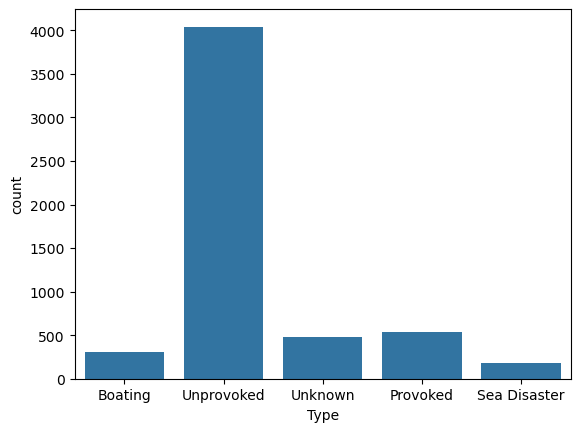

In [16]:
df ['Type'] = df ['Type'].replace({'Unprovoked':'Unprovoked',
                                  'Provoked' : 'Provoked',
                                  'Invalid' : 'Unknown',
                                  'Sea Disaster' : 'Sea Disaster',
                                  'Watercraft' : 'Boating',
                                  'Boat' : 'Boating',
                                  'Questionable' : 'Unknown',
                                  'Unconfirmed' : 'Unknown',
                                  'Unverified' : 'Unknown',
                                  'Under investigation' : 'Unknown',
                                  'Boatomg' : 'Boating'})
sns.countplot(x='Type', data = df)

### Country

In [19]:
df ['Country'].value_counts()

Country
USA                 2082
AUSTRALIA           1180
SOUTH AFRICA         548
PAPUA NEW GUINEA     130
BRAZIL               108
                    ... 
WESTERN SAMOA          1
BANGLADESH             1
SOUTH CHINA SEA        1
NAMIBIA                1
CYPRUS                 1
Name: count, Length: 178, dtype: int64

North : 1
 South : 0

In [22]:
df['Hemisphere'] = df['Country'].replace({
    'CROATIA': 1, 'NORWAY': 1, 'FRANCE': 1, 'MARTINIQUE': 1, 'ICELAND': 1,
    'JAVA': 0, 'Sierra Leone': 1, 'SIERRA LEONE': 1, 'CYPRUS': 1, 'LIBERIA': 1,
    'NEW BRITAIN': 0, 'URUGUAY': 0, 'NORTH ATLANTIC OCEAN ': 1, 'ADMIRALTY ISLANDS': 0,
    'PAPUA NEW GUINEA': 0, 'DJIBOUTI': 1, 'TAIWAN': 1, 'EL SALVADOR': 1,
    'ST. MAARTIN': 1, 'ASIA?': 1, 'NAMIBIA': 0, 'OCEAN': 0, 'CAPE VERDE': 1,
    'MID ATLANTIC OCEAN': 1, 'MAURITIUS': 0, 'ANTIGUA': 1, 'FRENCH POLYNESIA': 0,
    'JOHNSTON ISLAND': 1, 'SUDAN': 1, 'SOUTH KOREA': 1, 'TUVALU': 0,
    'SOUTH ATLANTIC OCEAN': 0, 'UNITED ARAB EMIRATES (UAE)': 1, 'DOMINICAN REPUBLIC': 1,
    ' PHILIPPINES': 1, 'MALAYSIA': 1, 'BRITISH VIRGIN ISLANDS': 1, 'CHINA': 1,
    'ATLANTIC OCEAN': 1, 'ITALY': 1, 'VENEZUELA': 1, 'SOLOMON ISLANDS / VANUATU': 0,
    'SOUTH CHINA SEA': 1, 'Between PORTUGAL & INDIA': 1, 'DIEGO GARCIA': 0,
    'MEDITERRANEAN SEA?': 1, 'INDIAN OCEAN?': 0, 'INDIA': 1, 'SOUTH AFRICA': 0,
    'St Helena': 0, 'WESTERN SAMOA': 0, 'TASMAN SEA': 0, 'HONG KONG': 1, 'TONGA': 0,
    'YEMEN': 1, 'COLUMBIA': 1, 'NORTHERN MARIANA ISLANDS': 1, 'GUAM': 1, 'GUINEA': 1,
    'CENTRAL PACIFIC': 0, 'GUATEMALA': 1, 'FIJI': 0, 'Fiji': 0, 'GULF OF ADEN': 1,
    'JAPAN': 1, 'MID-PACIFC OCEAN': 1, 'ST. MARTIN': 0, 'USA': 1, 'CRETE': 1, 'BRAZIL': 0,
    'TURKS & CAICOS': 1, 'SOUTHWEST PACIFIC OCEAN': 0, 'GREENLAND': 1,
    'BAY OF BENGAL': 0, 'PACIFIC OCEAN': 1, 'LEBANON': 1, 'MALTA': 1, 'NIGERIA': 1,
    'GREECE': 1, 'MEXICO': 1, 'BERMUDA': 1, 'UNITED KINGDOM': 1, 'SINGAPORE': 1,
    'BRITISH ISLES': 1, 'TURKEY': 1, 'NEVIS': 0, 'AUSTRALIA': 0, 'ENGLAND': 1,
    'VANUATU': 0, 'NORTH SEA': 1, 'RUSSIA': 1, 'MICRONESIA': 1, 'PORTUGAL': 1,
    'RED SEA': 1, 'MONTENEGRO': 1, 'IRAQ': 1, 'SWEDEN': 1, 'PERSIAN GULF': 1,
    'NORTH ATLANTIC OCEAN': 1, 'SLOVENIA': 1, 'PHILIPPINES': 1, 'IRAN / IRAQ': 1,
    'TUNISIA': 1, 'SAN DOMINGO': 0, 'AZORES': 1, 'GEORGIA': 1, 'BURMA': 1,
    'NEW GUINEA': 0, 'SUDAN?': 1, 'NETHERLANDS ANTILLES': 1, 'ALGERIA': 1,
    'NICARAGUA': 1, 'SEYCHELLES': 0, 'Seychelles': 0, 'RED SEA?': 1,
    'BRITISH NEW GUINEA': 0, 'THAILAND': 1, 'PALESTINIAN TERRITORIES': 1,
    'FALKLAND ISLANDS': 0, 'IRELAND': 1, 'MONACO': 1, 'PARAGUAY': 0, 'SYRIA': 1,
    'EGYPT ': 1, 'MADAGASCAR': 0, 'NORTH PACIFIC OCEAN': 1, 'EGYPT / ISRAEL': 1,
    'COOK ISLANDS': 0, 'TRINIDAD & TOBAGO': 1, 'PACIFIC OCEAN ': 1,
    'EQUATORIAL GUINEA / CAMEROON': 1, 'ISRAEL': 1, 'SAMOA': 0, 'ECUADOR': 0,
    'CARIBBEAN SEA': 1, 'NEW CALEDONIA': 0, 'MARSHALL ISLANDS': 1, 'PANAMA': 1,
    'UNITED ARAB EMIRATES': 1, 'ITALY / CROATIA': 1, 'NEW ZEALAND': 0,
    'MALDIVE ISLANDS': 1, 'GHANA': 1, 'MOZAMBIQUE': 0, 'SRI LANKA': 1,
    'SOLOMON ISLANDS': 0, 'Coast of AFRICA': 0, 'BARBADOS': 1, 'BANGLADESH': 1,
    'CHILE': 0, 'CANADA': 1, 'HONDURAS': 1, 'PALAU': 1, 'AMERICAN SAMOA': 0,
    'SAUDI ARABIA': 1, ' TONGA': 0, 'SPAIN': 1, 'ARGENTINA': 0, 'CURACAO': 1,
    'ANDAMAN / NICOBAR ISLANDAS': 1, 'KENYA': 0, 'EGYPT': 1, 'THE BALKANS': 1,
    'PUERTO RICO': 1, 'KIRIBATI': 1, 'OKINAWA': 1, 'REUNION': 0,
    'BRITISH WEST INDIES': 1, 'NICARAGUA ': 1, 'FEDERATED STATES OF MICRONESIA': 1,
    'IRAN': 1, 'CAYMAN ISLANDS': 1, 'SOMALIA': 1, 'INDONESIA': 0, 'KUWAIT': 1,
    'COSTA RICA': 1, 'INDIAN OCEAN': 0, 'CEYLON (SRI LANKA)': 1, 'YEMEN ': 1,
    'HAITI': 1, 'SCOTLAND': 1, 'CUBA': 1, 'GUYANA': 0, 'LIBYA': 1,
    'MEXICO ': 1, 'SENEGAL': 1, 'GRAND CAYMAN': 1, 'GABON': 0, 'GRENADA': 1,
    'RED SEA / INDIAN OCEAN': 1, 'VIETNAM': 1, 'BAHAMAS': 1, 'BAHREIN': 1,
    'NORTHERN ARABIAN SEA': 1, 'BELIZE': 1, 'MEDITERRANEAN SEA': 1,
    'ANGOLA': 0, 'SOUTH PACIFIC OCEAN': 0, 'TANZANIA': 0, 'KOREA': 1,
    'JAMAICA': 1, 'ARUBA': 1, 'MAYOTTE': 0, 'COLOMBIA': 0, 'REUNION ISLAND': 0,
    'MALDIVES': 0, 'COMOROS': 0, 'ST HELENA, British overseas territory': 0,
    'WEST INDIES': 1, 'CEYLON': 1, 'ANDAMAN ISLANDS': 1, 'TOBAGO': 1,
    'PERU': 0, 'AFRICA': 0, 'ROATAN': 1
})

([0, 1], [Text(0, 0, '0.0'), Text(1, 0, '1.0')])

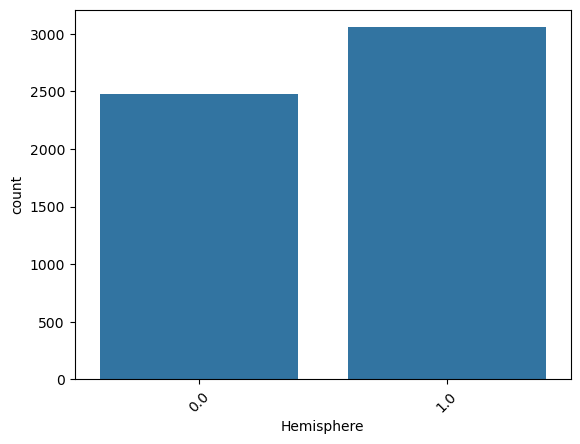

In [24]:
sns.countplot(x='Hemisphere', data = df) 
plt.xticks (rotation=45)

## Ocean Type

## 0 - Pacific Ocean 
1 - Atlantic 
2 - Indian 
3 - Artic 
4 - Southern Ocean 
5 - No Oncean 

In [28]:
ocean_mapping = {
 
    'NORWAY': 'Atlantic',
    'FRANCE': 'Atlantic',
    'MARTINIQUE': 'Atlantic',
    'ICELAND': 'Atlantic',
    'SIERRA LEONE': 'Atlantic',
    'LIBERIA': 'Atlantic',
    'URUGUAY': 'Atlantic',
    'ST. MAARTIN': 'Atlantic',
    'NAMIBIA': 'Atlantic',
    'CAPE VERDE': 'Atlantic',
    'MID ATLANTIC OCEAN': 'Atlantic',
    'ANTIGUA': 'Atlantic',
    'DOMINICAN REPUBLIC': 'Atlantic',
    'VENEZUELA': 'Atlantic',
    'BRAZIL': 'Atlantic',
    'AZORES': 'Atlantic',
    'ST HELENA, British overseas territory': 'Atlantic',
    'ST. MARTIN': 'Atlantic',
    'BERMUDA': 'Atlantic',
    'FALKLAND ISLANDS': 'Atlantic',
    'SAN DOMINGO': 'Atlantic',
    'TRINIDAD & TOBAGO': 'Atlantic',
    'COLOMBIA': 'Atlantic',
    'CUBA': 'Atlantic',
    'BARBADOS': 'Atlantic',
    'SENEGAL': 'Atlantic',
    'ANGOLA': 'Atlantic',
    'GABON': 'Atlantic',
    'ARGENTINA': 'Atlantic',
    'GHANA': 'Atlantic',


    'INDIA': 'Indian',
    'SEYCHELLES': 'Indian',
    'DIEGO GARCIA': 'Indian',
    'REUNION': 'Indian',
    'MADAGASCAR': 'Indian',
    'MALDIVES': 'Indian',
    'COMOROS': 'Indian',
    'KENYA': 'Indian',
    'TANZANIA': 'Indian',
    'SOUTH AFRICA': 'Indian',
    'INDIAN OCEAN': 'Indian',
    'INDIAN OCEAN?': 'Indian',
    'MAYOTTE': 'Indian',
    'REUNION ISLAND': 'Indian',


    'GREENLAND': 'Arctic',
    'NORWAY': 'Arctic', 
    'RUSSIA': 'Arctic',
    
    'ANTARCTICA': 'Southern',
    'SOUTH GEORGIA': 'Southern',
    'SOUTH SANDWICH ISLANDS': 'Southern',
    'FALKLAND ISLANDS': 'Southern', 

    
    'NEW ZEALAND': 'Pacific',
    'FIJI': 'Pacific',
    'TONGA': 'Pacific',
    'SOLOMON ISLANDS': 'Pacific',
    'AUSTRALIA': 'Pacific',
    'TUVALU': 'Pacific',
    'PAPUA NEW GUINEA': 'Pacific',
    'CHILE': 'Pacific',
    'JAPAN': 'Pacific',
    'PHILIPPINES': 'Pacific',
    'MALAYSIA': 'Pacific',
    'INDONESIA': 'Pacific',
    'FRENCH POLYNESIA': 'Pacific',
    'AMERICAN SAMOA': 'Pacific',
    'SAMOA': 'Pacific',
    'ECUADOR': 'Pacific',
    'NEW CALEDONIA': 'Pacific',
    'SOLOMON ISLANDS / VANUATU': 'Pacific',
    'COOK ISLANDS': 'Pacific',
    'SOUTH PACIFIC OCEAN': 'Pacific',
    'CENTRAL PACIFIC': 'Pacific',

    # No Ocean
    'CROATIA': 'No Ocean',
    'CYPRUS': 'No Ocean',
    'DJIBOUTI': 'No Ocean',
    'EL SALVADOR': 'No Ocean',
    'USA': 'No Ocean',
    'GERMANY': 'No Ocean',
    'IRAN': 'No Ocean',
    'IRAQ': 'No Ocean',
    'PALESTINIAN TERRITORIES': 'No Ocean',
    'NEPAL': 'No Ocean',
    'AUSTRIA': 'No Ocean',
    'AFGHANISTAN': 'No Ocean',
    'HUNGARY': 'No Ocean',
    'CZECH REPUBLIC': 'No Ocean',
    'SWITZERLAND': 'No Ocean',
    'PARAGUAY': 'No Ocean',
    'MEXICO': 'No Ocean',
    'COSTA RICA': 'No Ocean',
   
}
df['ocean']=df['Country'].map(ocean_mapping)



([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'No Ocean'),
  Text(1, 0, 'Pacific'),
  Text(2, 0, 'Atlantic'),
  Text(3, 0, 'Indian'),
  Text(4, 0, 'Arctic'),
  Text(5, 0, 'Southern')])

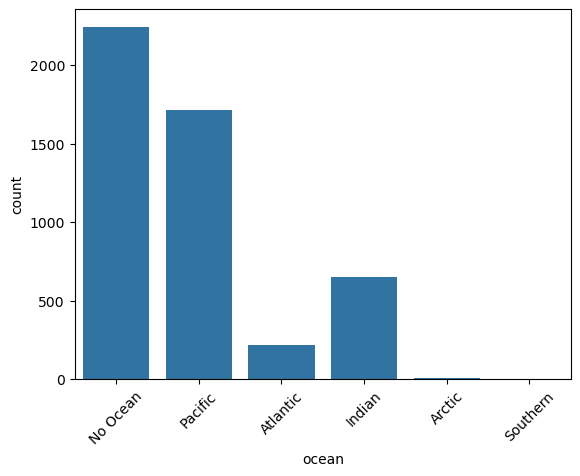

In [30]:
sns.countplot(x='ocean', data = df) 
plt.xticks (rotation=45)

### Gender

In [33]:
df ['Sex '].value_counts()

Sex 
M      4470
F       600
M         2
lli       1
N         1
.         1
Name: count, dtype: int64

In [35]:
df['Sex '] = df['Sex '].replace({
    'F': 'Female',
    'M ': 'Male',
    'M':'Male',
    'N': 'Unknown',
    'lli': 'Unknown',  
    '.': 'Unknown'})

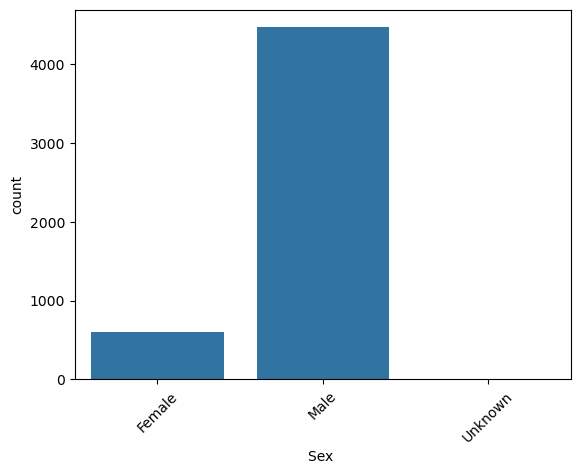

In [37]:
sns.countplot(x= 'Sex ', data = df)
plt.xticks (rotation=45);

### Fatal

In [40]:
df ['Fatal (Y/N)'].value_counts()

Fatal (Y/N)
N          4004
Y          1027
UNKNOWN      55
 N            7
M             1
2017          1
N             1
Name: count, dtype: int64

In [42]:
df ['Fatal'] = df ['Fatal (Y/N)'].replace({'N' : 'N', 'Y' : 'Y', 'UNKNOWN' : 'UNKNOWN',' N':'N','N ':'N',
                                           'F' : 'UNKNOWN', 'M':'UNKNOWN', '2017':'UNKNOWN', 'y' :'Y'})

In [44]:
df ['Fatal'].value_counts()

Fatal
N          4012
Y          1027
UNKNOWN      57
Name: count, dtype: int64

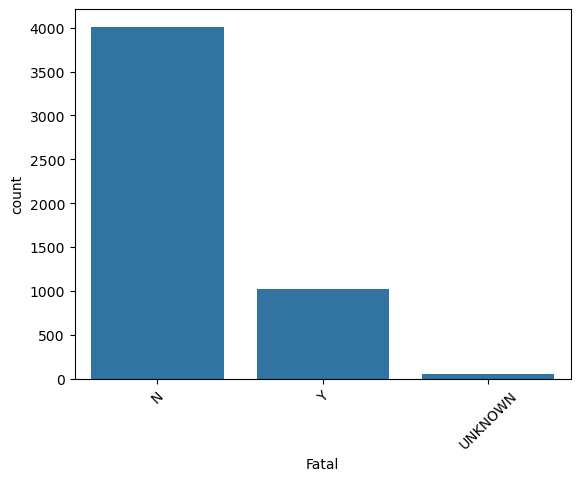

In [46]:
sns.countplot(x = 'Fatal', data = df)
plt.xticks (rotation=45);

### Activity

In [49]:
df ['Activity'].value_counts()[:20]

Activity
Surfing            968
Swimming           753
Fishing            379
Spearfishing       333
Wading             143
Diving             104
Standing            92
Snorkeling          88
Bathing             75
Scuba diving        75
Body boarding       61
Body surfing        49
Swimming            44
Kayaking            33
Treading water      32
Boogie boarding     29
Free diving         27
Pearl diving        22
Windsurfing         19
Walking             17
Name: count, dtype: int64

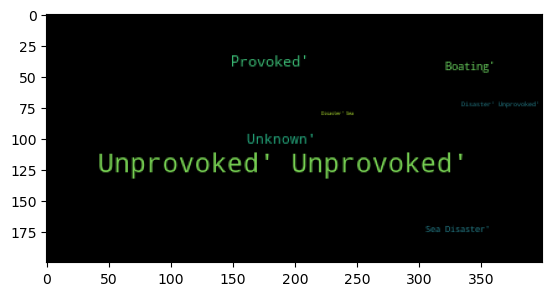

In [51]:
from wordcloud import WordCloud
words = df['Type'].tolist()
words = ''.join(str(words))
plt.imshow(WordCloud().generate(words))

In [53]:
# Function to replace activity names based on conditions
def replace_activity(activity):
    activity_lower = str(activity).lower()  # Case insensitive comparison
    if 'surf' in activity_lower:
        return 'surfing'
    elif 'fish' in activity_lower:
        return 'fishing'
    elif 'board' in activity_lower:
        return 'boarding'
    elif 'swim' in activity_lower:
        return 'swimming'
    elif 'div' in activity_lower:
        return 'diving'
    else:
        return 'other'

# Apply the function to the 'Activity' column
df['Activity'] = df['Activity'].apply(replace_activity)


<Axes: xlabel='Activity', ylabel='count'>

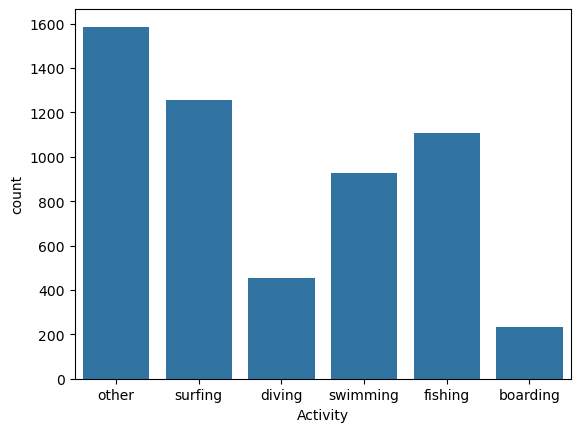

In [55]:
sns.countplot(x='Activity', data=df)

### Species 

In [58]:
# Get top 100 species counts
species_counts = df['Species '].value_counts()[:200]

# Print each species and its count one at a time
for species, count in species_counts.items():
    print(f"{species}: {count}")

White shark: 156
Shark involvement prior to death was not confirmed: 105
Invalid: 91
Shark involvement not confirmed: 86
Tiger shark: 69
Bull shark: 47
4' shark: 40
6' shark: 38
Questionable incident: 34
1.8 m [6'] shark: 33
1.5 m [5'] shark: 31
Shark involvement prior to death unconfirmed: 28
1.2 m [4'] shark: 26
5' shark: 25
Questionable: 25
3' shark: 25
2 m shark: 25
4' to 5' shark: 23
Wobbegong shark: 21
No shark involvement: 21
3 m [10'] shark: 20
3' to 4' shark: 18
3 m shark: 17
2.4 m [8'] shark: 16
3.7 m [12'] shark: 15
Blacktip shark: 15
1.2 m to 1.5 m [4' to 5'] shark: 14
Blue shark: 14
Mako shark: 13
"a small shark": 13
Shark involvement prior to death not confirmed: 13
6 m [20'] white shark: 12
Bronze whaler shark: 12
5 m [16.5'] white shark: 12
Raggedtooth shark: 12
Nurse shark: 12
7' shark: 12
1.5 m shark: 12
Zambesi shark: 11
Grey nurse shark: 11
12' shark: 11
4 m [13'] white shark: 10
2.1 m [7'] shark: 9
1 m shark: 9
a small shark: 9
10' shark: 9
White shark, 4 m [13'] :

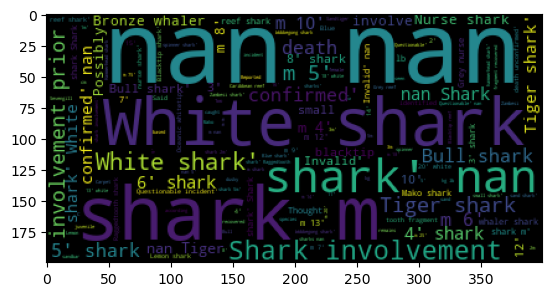

In [60]:
from wordcloud import WordCloud
words = df['Species '].tolist()
words = ''.join(str(words))
plt.imshow(WordCloud().generate(words))

In [61]:

# Define reef sharks
reef_sharks = ["Galapagos Shark", "Raggedtooth Shark", "Zambezi Shark", "Caribbean Reef Shark"]

# Function to classify species
def classify_shark(species):
    species_lower = str(species).lower()
    
    if "white" in species_lower and "shark" in species_lower:
        return "White Shark"
    elif "tiger" in species_lower and "shark" in species_lower:
        return "Tiger Shark"
    elif "bull" in species_lower and "shark" in species_lower:
        return "Bull Shark"
    elif "blue" in species_lower and "shark" in species_lower:
        return "Blue Shark"
    elif "tip" in species_lower and "shark" in species_lower:  # Covers all sharks with 'tip', including Blacktip Shark
        return "Whitetip Shark"
    elif any(shark.lower() in species_lower for shark in reef_sharks) or "reef" in species_lower:
        return "Reef Shark"
    elif "nurse" in species_lower and "shark" in species_lower: 
        return "Nurse Shark"
    elif ('no' in species_lower or 'not' in species_lower) and 'involvement' in species_lower:
        return 'No Shark' 
    else:
        return "Other Species"  # Mako Shark & Nurse Shark go here

# Apply classification
df['Classified Species'] = df['Species '].apply(classify_shark)

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'White Shark'),
  Text(1, 0, 'Other Species'),
  Text(2, 0, 'Tiger Shark'),
  Text(3, 0, 'Bull Shark'),
  Text(4, 0, 'Reef Shark'),
  Text(5, 0, 'Nurse Shark'),
  Text(6, 0, 'No Shark'),
  Text(7, 0, 'Whitetip Shark'),
  Text(8, 0, 'Blue Shark')])

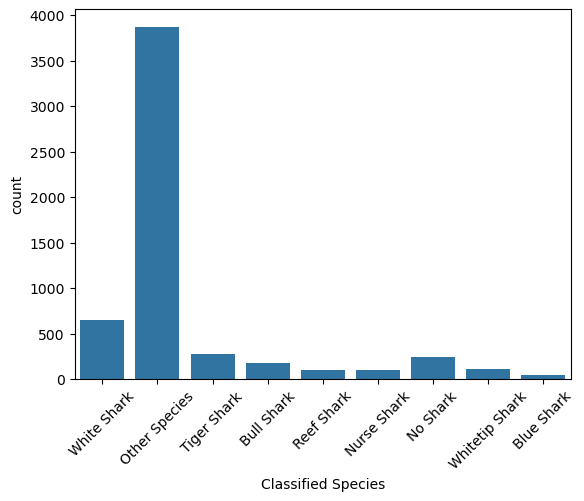

In [64]:
sns.countplot(x='Classified Species', data=df)
plt.xticks(rotation = 45)

### Date

In [67]:
import re
import pandas as pd

def extract_date(case_number):
    # Convert to string, strip whitespace
    case_str = str(case_number).strip()

    # Extract date pattern using regex
    match = re.match(r'(\d{4})[.-](\d{2})[.-](\d{2})', case_str)
    if not match:
        return None  # Skip if it doesn't match a date-like format

    year, month, day = match.groups()

    # Fix '00' values
    month = '01' if month == '00' else month
    day = '01' if day == '00' else day

    return f"{year}.{month}.{day}"

# Apply and convert to datetime
df['Date'] = pd.to_datetime(df['Case Number'].apply(extract_date), format='%Y.%m.%d', errors='coerce')


In [69]:
df['Date']

0      2018-06-25
1      2018-06-18
2      2018-06-09
3      2018-06-08
4      2018-06-04
          ...    
5556   1900-09-05
5557   1900-08-21
5558   1900-07-31
5559   1900-07-14
5560   1900-07-01
Name: Date, Length: 5561, dtype: datetime64[ns]

### Weekend

<Axes: xlabel='is_weekend', ylabel='count'>

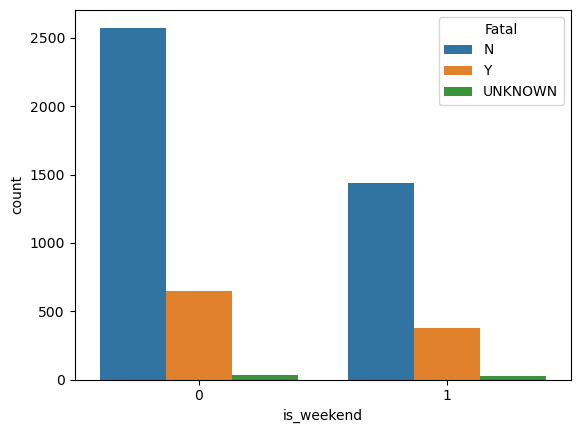

In [72]:
df['is_weekend'] = df['Date'].dt.weekday.isin([5, 6]).astype(int)

sns.countplot(x='is_weekend', data=df,hue='Fatal')

### Time

In [75]:
df['Time'].value_counts()

Time
Afternoon    200
Morning      133
11h00        128
15h00        109
12h00        105
            ... 
10h27          1
15j45          1
15h44          1
13h51          1
evening        1
Name: count, Length: 277, dtype: int64

Early morning: 05h00 – 07h59

Morning: 08h00 – 11h59

Midday: 12h00 – 13h59

Afternoon: 14h00 – 17h59

Evening: 18h00 – 20h59

Night: 21h00 – 04h59

In [78]:

def map_time_to_category(time_str: str) -> str:
    original_input = time_str  # Preserve original for unclear fallback
    time_str = str(time_str).lower().strip()

    # Map based on keywords
    keyword_map = {
        "morning": "Morning",
        "early morning": "Morning",
        "dawn": "Morning",
        "afternoon": "Afternoon",
        "late afternoon": "Afternoon",
        "after noon": "Afternoon",
        "lunchtime": "Afternoon",
        "evening": "Evening",
        "sunset": "Evening",
        "dusk": "Evening",
        "night": "Night",
        "midnight": "Night"
    }

    if time_str in keyword_map:
        return keyword_map[time_str]

    # Match HHhMM format (e.g., 07h30)
    match = re.match(r"^(\d{1,2})h(\d{2})$", time_str)
    if match:
        hour = int(match.group(1))
        if 5 <= hour < 12:
            return "Morning"
        elif 12 <= hour < 17:
            return "Afternoon"
        elif 17 <= hour < 21:
            return "Evening"
        else:
            return "Night"

    return f"Unclear: {original_input}"

df['Time'].apply(map_time_to_category).unique()

array(['Evening', 'Afternoon', 'Morning', 'Unclear: nan', 'Night',
       'Unclear: 1300', 'Unclear: 09h30 / 10h00', 'Unclear: 18h15-18h30',
       'Unclear: 15j45', 'Unclear: 11h115', 'Unclear:   ',
       'Unclear: Between 05h00 and 08h00', 'Unclear:  ', 'Unclear: \xa0 ',
       'Unclear: 20h45 (Sunset)', 'Unclear: 18h30 (Sunset)',
       'Unclear: 06j00', 'Unclear: AM', 'Unclear: 16h30 or 18h00',
       'Unclear: Aftermoon', 'Unclear: 09h30 / 15h30',
       'Unclear: Between 11h00 & 12h00'], dtype=object)

In [80]:
import pandas as pd
import re
import numpy as np

def categorize_time(value):
    # Normalize to lowercase
    value = str(value).lower().strip()

    # Define keyword-based mapping
    if 'morning' in value:
        return 'morning'
    elif 'afternoon' in value:
        return 'afternoon'
    elif 'evening' in value:
        return 'evening'
    elif 'night' in value:
        return 'night'

    # Extract "hour h minute" using regex
    match = re.search(r'(\d{1,2})\s*hour[s]?\s*(\d{1,2})?\s*minute[s]?', value)
    if match:
        hour = int(match.group(1))
        minute = int(match.group(2)) if match.group(2) else 0
        total_minutes = hour * 60 + minute

        # Categorize by time ranges
        if 300 <= total_minutes < 720:
            return 'morning'   # 5:00–12:00
        elif 720 <= total_minutes < 1020:
            return 'afternoon'  # 12:00–17:00
        elif 1020 <= total_minutes < 1260:
            return 'evening'  # 17:00–21:00
        else:
            return 'night'    # 21:00–5:00
    return np.nan  # Unparseable or missing

df['time_category'] = df['Time'].apply(categorize_time)


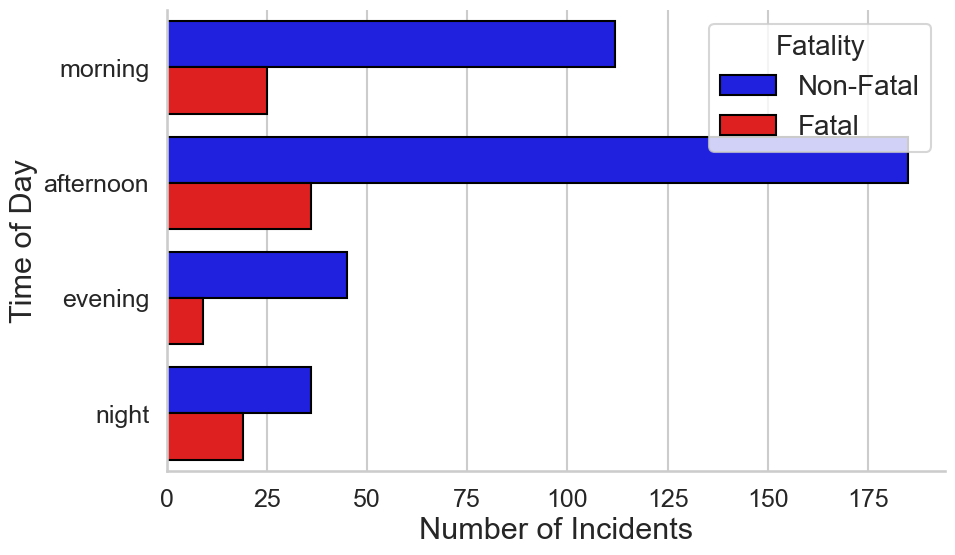

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

# Categorize time of day
def categorize_time(value):
    value = str(value).lower().strip()
    if 'morning' in value:
        return 'morning'
    elif 'afternoon' in value:
        return 'afternoon'
    elif 'evening' in value:
        return 'evening'
    elif 'night' in value:
        return 'night'

    # Match "X hour Y minute" pattern
    match = re.search(r'(\d{1,2})\s*hour[s]?\s*(\d{1,2})?\s*minute[s]?', value)
    if match:
        hour = int(match.group(1))
        minute = int(match.group(2)) if match.group(2) else 0
        total_minutes = hour * 60 + minute

        if 300 <= total_minutes < 720:
            return 'morning'    # 5:00–12:00
        elif 720 <= total_minutes < 1020:
            return 'afternoon' # 12:00–17:00
        elif 1020 <= total_minutes < 1260:
            return 'evening'   # 17:00–21:00
        else:
            return 'night'     # 21:00–5:00

    return np.nan

# Apply categorization
df['time_category'] = df['Time'].apply(categorize_time)

# Filter to valid time categories and fatality values
df_time = df[df['Fatal'].isin(['Y', 'N']) & df['time_category'].notna()].copy()

# Group and count
time_counts = (
    df_time.groupby(['time_category', 'Fatal'])
    .size()
    .reset_index(name='count')
)

# Sort time categories in logical order
order = ['morning', 'afternoon', 'evening', 'night']
time_counts['time_category'] = pd.Categorical(time_counts['time_category'], categories=order, ordered=True)
time_counts = time_counts.sort_values('time_category')

# Set color palette for fatality: red = fatal, blue = non-fatal
palette = {
    'Y': 'red',
    'N': 'blue'
}

# Plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid", context="talk", font_scale=1.2)

ax = sns.barplot(
    data=time_counts,
    y='time_category',
    x='count',
    hue='Fatal',
    palette=palette,
    edgecolor='black'
)

# Labels and title

plt.xlabel('Number of Incidents', fontsize=22)
plt.ylabel('Time of Day', fontsize=22)

# Legend improvement
legend_labels = {'N': 'Non-Fatal', 'Y': 'Fatal'}
handles, labels = ax.get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l in legend_labels]
handles, labels = zip(*filtered)
ax.legend(handles=handles, labels=[legend_labels[l] for l in labels], title='Fatality', title_fontsize=20, fontsize=20, loc='upper right')

ax.tick_params(axis='y', labelsize=18)
# Format y-axis tick labels
ax.tick_params(axis='x', labelsize=18)

# Clean up
sns.despine()
plt.tight_layout()
plt.show()


([0, 1, 2, 3],
 [Text(0, 0, 'afternoon'),
  Text(1, 0, 'morning'),
  Text(2, 0, 'night'),
  Text(3, 0, 'evening')])

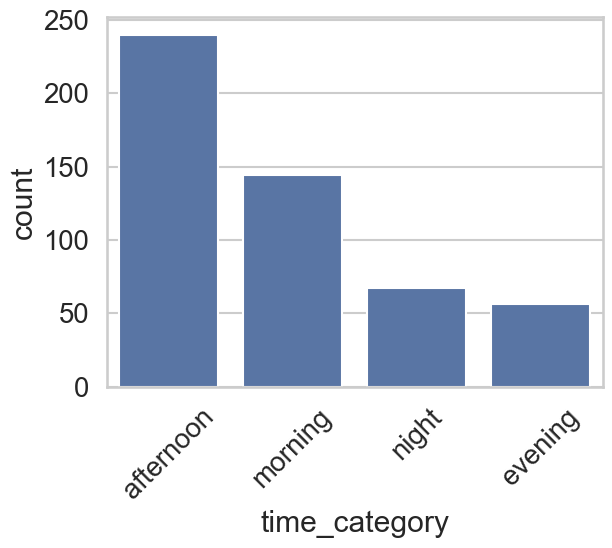

In [84]:
sns.countplot(x='time_category', data=df)
plt.xticks(rotation = 45)

In [86]:
df['time_category'].value_counts()

time_category
afternoon    240
morning      144
night         67
evening       56
Name: count, dtype: int64

In [88]:
df

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Fatal (Y/N),Time,Species,original order,Hemisphere,ocean,Fatal,Classified Species,is_weekend,time_category
0,2018.06.25,2018-06-25,2018.0,Boating,USA,California,"Oceanside, San Diego County",other,Julie Wolfe,Female,...,N,18h00,White shark,6303,1.0,No Ocean,N,White Shark,0,NaN
1,2018.06.18,2018-06-18,2018.0,Unprovoked,USA,Georgia,"St. Simon Island, Glynn County",other,Adyson McNeely,Female,...,N,14h00,NaN,6302,1.0,No Ocean,N,Other Species,0,NaN
2,2018.06.09,2018-06-09,2018.0,Unknown,USA,Hawaii,"Habush, Oahu",surfing,John Denges,Male,...,N,07h45,NaN,6301,1.0,No Ocean,N,Other Species,1,NaN
3,2018.06.08,2018-06-08,2018.0,Unprovoked,AUSTRALIA,New South Wales,Arrawarra Headland,surfing,male,Male,...,N,NaN,2 m shark,6300,0.0,Pacific,N,Other Species,0,NaN
4,2018.06.04,2018-06-04,2018.0,Provoked,MEXICO,Colima,La Ticla,diving,Gustavo Ramos,Male,...,N,NaN,"Tiger shark, 3m",6299,1.0,No Ocean,N,Tiger Shark,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5556,1900.09.05,1900-09-05,1900.0,Unprovoked,USA,Hawaii,"Waikiki Beach, Oahu",other,Joe Hartman,Male,...,N,Afternoon,NaN,747,1.0,No Ocean,N,Other Species,0,afternoon
5557,1900.08.21,1900-08-21,1900.0,Unprovoked,USA,North Carolina,"Southport, Brunswick County",other,Burris,Male,...,N,Afternoon,NaN,746,1.0,No Ocean,N,Other Species,0,afternoon
5558,1900.07.31,1900-07-31,1900.0,Unprovoked,CROATIA,Primorje-Gorski Kotar County,"Volosko, Opatija",swimming,male,Male,...,Y,NaN,NaN,745,1.0,No Ocean,Y,Other Species,0,NaN
5559,1900.07.14,1900-07-14,1900.0,Unknown,USA,Hawaii,"Makapu'u Point, O'ahu",other,Emil Uhlbrecht & unidentified person,Male,...,NaN,NaN,Questionable,744,1.0,No Ocean,NaN,Other Species,1,NaN


## Model

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5561 entries, 0 to 5560
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Case Number         5560 non-null   object        
 1   Date                5559 non-null   datetime64[ns]
 2   Year                5560 non-null   float64       
 3   Type                5558 non-null   object        
 4   Country             5537 non-null   object        
 5   Area                5248 non-null   object        
 6   Location            5183 non-null   object        
 7   Activity            5561 non-null   object        
 8   Name                5394 non-null   object        
 9   Sex                 5075 non-null   object        
 10  Age                 3366 non-null   float64       
 11  Injury              5542 non-null   object        
 12  Fatal (Y/N)         5096 non-null   object        
 13  Time                2838 non-null   object      

In [93]:
df_final = df[['Fatal','Type','Activity','Sex ','Hemisphere','ocean','Classified Species', 'is_weekend']].dropna()
df_final = df_final[df_final['Fatal'] != 'UNKNOWN']
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4055 entries, 0 to 5558
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Fatal               4055 non-null   object 
 1   Type                4055 non-null   object 
 2   Activity            4055 non-null   object 
 3   Sex                 4055 non-null   object 
 4   Hemisphere          4055 non-null   float64
 5   ocean               4055 non-null   object 
 6   Classified Species  4055 non-null   object 
 7   is_weekend          4055 non-null   int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 285.1+ KB


In [95]:
df_final['Fatal'].value_counts()

Fatal
N    3303
Y     752
Name: count, dtype: int64

In [97]:
y = df_final['Fatal']
X = df_final.drop(['Fatal'],axis = 1)

In [99]:
y

0       N
1       N
2       N
3       N
4       N
       ..
5552    Y
5554    N
5556    N
5557    N
5558    Y
Name: Fatal, Length: 4055, dtype: object

In [101]:
X

,Type,Activity,Sex,Hemisphere,ocean,Classified Species,is_weekend
0,Boating,other,Female,1.0,No Ocean,White Shark,0
1,Unprovoked,other,Female,1.0,No Ocean,Other Species,0
2,Unknown,surfing,Male,1.0,No Ocean,Other Species,1
3,Unprovoked,surfing,Male,0.0,Pacific,Other Species,0
4,Provoked,diving,Male,1.0,No Ocean,Tiger Shark,0
...,...,...,...,...,...,...,...
5552,Unprovoked,swimming,Male,0.0,Indian,Other Species,0
5554,Unprovoked,swimming,Male,0.0,Pacific,Other Species,1
5556,Unprovoked,other,Male,1.0,No Ocean,Other Species,0
5557,Unprovoked,other,Male,1.0,No Ocean,Other Species,0


In [103]:
X_encoded = pd.get_dummies(X, columns = ['Type','Activity','Sex ','ocean','Classified Species'])
X_encoded

,Hemisphere,is_weekend,Type_Boating,Type_Provoked,Type_Sea Disaster,Type_Unknown,Type_Unprovoked,Activity_boarding,Activity_diving,Activity_fishing,...,ocean_Southern,Classified Species_Blue Shark,Classified Species_Bull Shark,Classified Species_No Shark,Classified Species_Nurse Shark,Classified Species_Other Species,Classified Species_Reef Shark,Classified Species_Tiger Shark,Classified Species_White Shark,Classified Species_Whitetip Shark
0,1.0,0,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,1.0,0,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,1.0,1,False,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0.0,0,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,1.0,0,False,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5552,0.0,0,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
5554,0.0,1,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
5556,1.0,0,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
5557,1.0,0,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [105]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Step 1: Split your data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, stratify = y, test_size=0.2, random_state=42)

# Step 2: Initialize and train the model
model = LogisticRegression(max_iter=1000,class_weight='balanced')  # Increase max_iter if needed
model.fit(X_train, y_train)
 
# Step 3: Predict on both train and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Step 4: Print classification reports
print("Classification Report - Training Set:")
print(classification_report(y_train, y_train_pred))

print("\nClassification Report - Test Set:")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set:
              precision    recall  f1-score   support

           N       0.93      0.69      0.79      2642
           Y       0.36      0.77      0.49       602

    accuracy                           0.71      3244
   macro avg       0.65      0.73      0.64      3244
weighted avg       0.82      0.71      0.74      3244


Classification Report - Test Set:
              precision    recall  f1-score   support

           N       0.93      0.68      0.78       661
           Y       0.35      0.77      0.48       150

    accuracy                           0.70       811
   macro avg       0.64      0.73      0.63       811
weighted avg       0.82      0.70      0.73       811



In [107]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, stratify=y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Logistic Regression - Train:")
print(classification_report(y_train, y_train_pred))
print("\nLogistic Regression - Test:")
print(classification_report(y_test, y_test_pred))


Logistic Regression - Train:
              precision    recall  f1-score   support

           N       0.93      0.69      0.79      2642
           Y       0.36      0.77      0.49       602

    accuracy                           0.71      3244
   macro avg       0.65      0.73      0.64      3244
weighted avg       0.82      0.71      0.74      3244


Logistic Regression - Test:
              precision    recall  f1-score   support

           N       0.93      0.68      0.78       661
           Y       0.35      0.77      0.48       150

    accuracy                           0.70       811
   macro avg       0.64      0.73      0.63       811
weighted avg       0.82      0.70      0.73       811



In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, stratify=y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Probabilities for class 'Y'
y_train_proba = model.predict_proba(X_train)[:, model.classes_.tolist().index('Y')]
y_test_proba = model.predict_proba(X_test)[:, model.classes_.tolist().index('Y')]

# PR AUC (Y as positive)
pr_auc_train = average_precision_score(y_train, y_train_proba, pos_label='Y')
pr_auc_test = average_precision_score(y_test, y_test_proba, pos_label='Y')

print("Logistic Regression - Train:")
print(classification_report(y_train, y_train_pred))
print(f"PR AUC (Train): {pr_auc_train:.4f}")

print("\nLogistic Regression - Test:")
print(classification_report(y_test, y_test_pred))
print(f"PR AUC (Test): {pr_auc_test:.4f}")


Logistic Regression - Train:
              precision    recall  f1-score   support

           N       0.93      0.69      0.79      2642
           Y       0.36      0.77      0.49       602

    accuracy                           0.71      3244
   macro avg       0.65      0.73      0.64      3244
weighted avg       0.82      0.71      0.74      3244

PR AUC (Train): 0.4563

Logistic Regression - Test:
              precision    recall  f1-score   support

           N       0.93      0.68      0.78       661
           Y       0.35      0.77      0.48       150

    accuracy                           0.70       811
   macro avg       0.64      0.73      0.63       811
weighted avg       0.82      0.70      0.73       811

PR AUC (Test): 0.4886


In [111]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Decision Tree - Train:")
print(classification_report(y_train, y_train_pred))
print("\nDecision Tree - Test:")
print(classification_report(y_test, y_test_pred))


Decision Tree - Train:
              precision    recall  f1-score   support

           N       0.95      0.73      0.82      2642
           Y       0.41      0.84      0.55       602

    accuracy                           0.75      3244
   macro avg       0.68      0.78      0.69      3244
weighted avg       0.85      0.75      0.77      3244


Decision Tree - Test:
              precision    recall  f1-score   support

           N       0.89      0.68      0.77       661
           Y       0.31      0.64      0.42       150

    accuracy                           0.68       811
   macro avg       0.60      0.66      0.60       811
weighted avg       0.79      0.68      0.71       811



In [113]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("KNN - Train:")
print(classification_report(y_train, y_train_pred))
print("\nKNN - Test:")
print(classification_report(y_test, y_test_pred))

from sklearn.metrics import average_precision_score

# Get predicted probabilities for the positive class ('Y')
y_train_prob = model.predict_proba(X_train)[:, list(model.classes_).index('Y')]
y_test_prob = model.predict_proba(X_test)[:, list(model.classes_).index('Y')]

# Compute PR AUC
train_pr_auc = average_precision_score(y_train.map({'N':0, 'Y':1}), y_train_prob)
test_pr_auc = average_precision_score(y_test.map({'N':0, 'Y':1}), y_test_prob)

print(f"KNN - Train PR AUC: {train_pr_auc:.4f}")
print(f"KNN - Test PR AUC: {test_pr_auc:.4f}")


KNN - Train:
              precision    recall  f1-score   support

           N       0.86      0.95      0.90      2642
           Y       0.59      0.32      0.42       602

    accuracy                           0.83      3244
   macro avg       0.73      0.63      0.66      3244
weighted avg       0.81      0.83      0.81      3244


KNN - Test:
              precision    recall  f1-score   support

           N       0.86      0.94      0.90       661
           Y       0.55      0.30      0.39       150

    accuracy                           0.82       811
   macro avg       0.70      0.62      0.64       811
weighted avg       0.80      0.82      0.80       811

KNN - Train PR AUC: 0.4512
KNN - Test PR AUC: 0.3882


In [115]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Random Forest - Train:")
print(classification_report(y_train, y_train_pred))
print("\nRandom Forest - Test:")
print(classification_report(y_test, y_test_pred))


Random Forest - Train:
              precision    recall  f1-score   support

           N       0.95      0.74      0.83      2642
           Y       0.42      0.81      0.55       602

    accuracy                           0.76      3244
   macro avg       0.68      0.78      0.69      3244
weighted avg       0.85      0.76      0.78      3244


Random Forest - Test:
              precision    recall  f1-score   support

           N       0.90      0.70      0.79       661
           Y       0.33      0.65      0.44       150

    accuracy                           0.69       811
   macro avg       0.61      0.68      0.61       811
weighted avg       0.79      0.69      0.72       811



In [117]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Convert labels
y_train = y_train.map({'N': 0, 'Y': 1})
y_test = y_test.map({'N': 0, 'Y': 1})

# Initialize and fit the model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluation
print("XGBoost - Train:")
print(classification_report(y_train, y_train_pred))
print("\nXGBoost - Test:")
print(classification_report(y_test, y_test_pred))


XGBoost - Train:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91      2642
           1       0.73      0.29      0.42       602

    accuracy                           0.85      3244
   macro avg       0.79      0.63      0.67      3244
weighted avg       0.83      0.85      0.82      3244


XGBoost - Test:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       661
           1       0.54      0.23      0.32       150

    accuracy                           0.82       811
   macro avg       0.69      0.59      0.61       811
weighted avg       0.79      0.82      0.79       811



In [119]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("ExtraTrees - Train:")
print(classification_report(y_train, y_train_pred))
print("\nExtraTrees - Test:")
print(classification_report(y_test, y_test_pred))


ExtraTrees - Train:
              precision    recall  f1-score   support

           0       0.95      0.73      0.82      2642
           1       0.41      0.84      0.55       602

    accuracy                           0.75      3244
   macro avg       0.68      0.78      0.69      3244
weighted avg       0.85      0.75      0.77      3244


ExtraTrees - Test:
              precision    recall  f1-score   support

           0       0.89      0.68      0.77       661
           1       0.31      0.65      0.42       150

    accuracy                           0.67       811
   macro avg       0.60      0.66      0.60       811
weighted avg       0.79      0.67      0.71       811



In [121]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("LightGBM - Train:")
print(classification_report(y_train, y_train_pred))
print("\nLightGBM - Test:")
print(classification_report(y_test, y_test_pred))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 602, number of negative: 2642
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001000 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 52
[LightGBM] [Info] Number of data points in the train set: 3244, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM - Train:
              precision    recall  f1-score   support

           0       0.95      0.71      0.81      2642
           1       0.40      0.83      0.54       602

    accuracy                           0.73      3244
   macro avg       0.67      0.77      0.67      3244
weighted avg       0.85      0.73      0.76      3244


LightGBM - Test:
     

In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import warnings

# Optional: Suppress warnings
warnings.filterwarnings('ignore')

# 1. Define Random Forest model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# 2. Define parameter grid (LightGBM-like structure)
param_grid = {
    'n_estimators': [100, 500],
    'min_samples_split': [20, 30, 40, 50, 60, 70],
    'max_features': range(2, 30, 2)
}

# 3. Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    verbose=3
)

# 4. Fit the grid search
grid_search.fit(X_train, y_train)

# 5. Best model and parameters
best_model_rf = grid_search.best_estimator_

# Create a display dict to mimic LightGBM’s format (no model logic changed)
best_params = grid_search.best_params_


print("Best Parameters:", best_params)

# 6. Predict on train and test sets
y_train_pred = best_model_rf.predict(X_train)
y_test_pred = best_model_rf.predict(X_test)

y_train_proba = best_model_rf.predict_proba(X_train)[:, 1]
y_test_proba = best_model_rf.predict_proba(X_test)[:, 1]

# 7. Classification Reports
print("\nRandom Forest - Train Classification Report:")
print(classification_report(y_train, y_train_pred))

print("\nRandom Forest - Test Classification Report:")
print(classification_report(y_test, y_test_pred))

# 8. ROC AUC and PR AUC
roc_auc_train = roc_auc_score(y_train, y_train_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

prauc_train = average_precision_score(y_train, y_train_proba)
prauc_test = average_precision_score(y_test, y_test_proba)

print(f"\nTrain ROC AUC: {roc_auc_train:.4f}")
print(f"Test ROC AUC: {roc_auc_test:.4f}")
print(f"Train PR AUC: {prauc_train:.4f}")
print(f"Test PR AUC: {prauc_test:.4f}")


Fitting 5 folds for each of 168 candidates, totalling 840 fits
[CV 1/5] END max_features=2, min_samples_split=20, n_estimators=100;, score=0.780 total time=   0.1s
[CV 2/5] END max_features=2, min_samples_split=20, n_estimators=100;, score=0.785 total time=   0.1s
[CV 3/5] END max_features=2, min_samples_split=20, n_estimators=100;, score=0.770 total time=   0.1s
[CV 4/5] END max_features=2, min_samples_split=20, n_estimators=100;, score=0.762 total time=   0.1s
[CV 5/5] END max_features=2, min_samples_split=20, n_estimators=100;, score=0.774 total time=   0.1s
[CV 1/5] END max_features=2, min_samples_split=20, n_estimators=500;, score=0.781 total time=   0.4s
[CV 2/5] END max_features=2, min_samples_split=20, n_estimators=500;, score=0.793 total time=   0.4s
[CV 3/5] END max_features=2, min_samples_split=20, n_estimators=500;, score=0.770 total time=   0.4s
[CV 4/5] END max_features=2, min_samples_split=20, n_estimators=500;, score=0.761 total time=   0.4s
[CV 5/5] END max_features=2,

In [239]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import warnings

# Optional: Suppress warnings
warnings.filterwarnings('ignore')

# 1. Define LightGBM model with logging turned down
lgbm = LGBMClassifier(
    objective='binary',
    random_state=42,
    verbosity=-1  # Suppresses most LightGBM messages
)

# 2. Define parameter grid (correct param names for LightGBM)
param_grid = {
    'n_estimators': [100, 500],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3]
}

# 3. Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    verbose=3,  # Shows progress of grid search
)

# 4. Fit the grid search
grid_search.fit(X_train, y_train)

# 5. Best model and parameters
best_model_lgbm = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# 6. Predict on train and test sets
y_train_pred = best_model_lgbm.predict(X_train)
y_test_pred = best_model_lgbm.predict(X_test)

y_train_proba = best_model_lgbm.predict_proba(X_train)[:, 1]
y_test_proba = best_model_lgbm.predict_proba(X_test)[:, 1]

# 7. Classification Reports
print("\nLightGBM - Train Classification Report:")
print(classification_report(y_train, y_train_pred))

print("\nLightGBM - Test Classification Report:")
print(classification_report(y_test, y_test_pred))

# 8. ROC AUC and PR AUC
roc_auc_train = roc_auc_score(y_train, y_train_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

prauc_train = average_precision_score(y_train, y_train_proba)
prauc_test = average_precision_score(y_test, y_test_proba)

print(f"\nTrain ROC AUC: {roc_auc_train:.4f}")
print(f"Test ROC AUC: {roc_auc_test:.4f}")
print(f"Train PR AUC: {prauc_train:.4f}")
print(f"Test PR AUC: {prauc_test:.4f}")


Fitting 5 folds for each of 250 candidates, totalling 1250 fits
[CV 1/5] END colsample_bytree=0.5, learning_rate=0.001, n_estimators=100, subsample=0.5;, score=0.732 total time=   0.2s
[CV 2/5] END colsample_bytree=0.5, learning_rate=0.001, n_estimators=100, subsample=0.5;, score=0.732 total time=   0.1s
[CV 3/5] END colsample_bytree=0.5, learning_rate=0.001, n_estimators=100, subsample=0.5;, score=0.730 total time=   0.1s
[CV 4/5] END colsample_bytree=0.5, learning_rate=0.001, n_estimators=100, subsample=0.5;, score=0.730 total time=   0.1s
[CV 5/5] END colsample_bytree=0.5, learning_rate=0.001, n_estimators=100, subsample=0.5;, score=0.732 total time=   0.1s
[CV 1/5] END colsample_bytree=0.5, learning_rate=0.001, n_estimators=100, subsample=0.6;, score=0.732 total time=   0.1s
[CV 2/5] END colsample_bytree=0.5, learning_rate=0.001, n_estimators=100, subsample=0.6;, score=0.732 total time=   0.1s
[CV 3/5] END colsample_bytree=0.5, learning_rate=0.001, n_estimators=100, subsample=0.6;,

In [125]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.metrics import make_scorer
import warnings
import numpy as np

# Optional: Suppress warnings
warnings.filterwarnings('ignore')

# 1. Define the model
et = ExtraTreesClassifier(class_weight='balanced', random_state=42)

# 2. Set up hyperparameter grid for tuning
param_grid = {
    'n_estimators': [100, 500],
    'min_samples_split': [20, 30, 40, 50, 60, 70],
    'max_features': range(2, 30, 2)
}

# 3. Define stratified K-Fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 4. Use ROC AUC as optional scoring metric
scorer = make_scorer(roc_auc_score, needs_proba=True)

# 5. Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=et,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_weighted',  # you can swap with `scorer` for ROC AUC scoring
    verbose=3
)

# 6. Fit the grid search
grid_search.fit(X_train, y_train)

# 7. Best model
best_model_et = grid_search.best_estimator_

# Create LightGBM-style display of best parameters
best_params = grid_search.best_params_

print("Best Parameters:", best_params)

# 8. Predict on train and test sets
y_train_pred = best_model_et.predict(X_train)
y_test_pred = best_model_et.predict(X_test)

y_train_proba = best_model_et.predict_proba(X_train)[:, 1]
y_test_proba = best_model_et.predict_proba(X_test)[:, 1]

# 9. Classification Reports
print("\nExtra Trees - Train Classification Report:")
print(classification_report(y_train, y_train_pred))

print("\nExtra Trees - Test Classification Report:")
print(classification_report(y_test, y_test_pred))

# 10. ROC AUC and PR AUC
roc_auc_train = roc_auc_score(y_train, y_train_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

prauc_train = average_precision_score(y_train, y_train_proba)
prauc_test = average_precision_score(y_test, y_test_proba)

print(f"\nTrain ROC AUC: {roc_auc_train:.4f}")
print(f"Test ROC AUC: {roc_auc_test:.4f}")
print(f"Train PR AUC: {prauc_train:.4f}")
print(f"Test PR AUC: {prauc_test:.4f}")


Fitting 3 folds for each of 168 candidates, totalling 504 fits
[CV 1/3] END max_features=2, min_samples_split=20, n_estimators=100;, score=0.739 total time=   0.1s
[CV 2/3] END max_features=2, min_samples_split=20, n_estimators=100;, score=0.722 total time=   0.1s
[CV 3/3] END max_features=2, min_samples_split=20, n_estimators=100;, score=0.742 total time=   0.1s
[CV 1/3] END max_features=2, min_samples_split=20, n_estimators=500;, score=0.738 total time=   0.4s
[CV 2/3] END max_features=2, min_samples_split=20, n_estimators=500;, score=0.721 total time=   0.4s
[CV 3/3] END max_features=2, min_samples_split=20, n_estimators=500;, score=0.740 total time=   0.4s
[CV 1/3] END max_features=2, min_samples_split=30, n_estimators=100;, score=0.737 total time=   0.1s
[CV 2/3] END max_features=2, min_samples_split=30, n_estimators=100;, score=0.717 total time=   0.1s
[CV 3/3] END max_features=2, min_samples_split=30, n_estimators=100;, score=0.737 total time=   0.1s
[CV 1/3] END max_features=2,

In [253]:
y_train = y_train.replace({'N': 0, 'Y': 1})
y_test = y_test.replace({'N': 0, 'Y': 1})
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# 1. Define XGBoost model
xgb = XGBClassifier(
    random_state=42,
)

# 2. Define parameter grid
param_grid = {
    'n_estimators': [100, 500],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
    'colsample_bynode': [0.5, 0.6, 0.7, 0.8, 0.9],  # Same as LightGBM
    'learning_rate': [0.001, 0.002, 0.003, 0.01, 0.02, 0.03, 0.1, 0.2, 0.3]
}

# 3. Define cross-validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 4. Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_weighted',
    verbose=3
)

# 5. Fit the grid search
grid_search.fit(X_train, y_train)

# 6. Best model
best_model_xgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# 7. Predict on train and test sets
y_train_pred = best_model_xgb.predict(X_train)
y_test_pred = best_model_xgb.predict(X_test)

y_train_proba = best_model_xgb.predict_proba(X_train)[:, 1]
y_test_proba = best_model_xgb.predict_proba(X_test)[:, 1]

# 8. Classification Reports
print("\nXGBoost - Train Classification Report:")
print(classification_report(y_train, y_train_pred))

print("\nXGBoost - Test Classification Report:")
print(classification_report(y_test, y_test_pred))

# 9. ROC AUC and PR AUC
roc_auc_train = roc_auc_score(y_train, y_train_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

prauc_train = average_precision_score(y_train, y_train_proba)
prauc_test = average_precision_score(y_test, y_test_proba)

print(f"\nTrain ROC AUC: {roc_auc_train:.4f}")
print(f"Test ROC AUC: {roc_auc_test:.4f}")
print(f"Train PR AUC: {prauc_train:.4f}")
print(f"Test PR AUC: {prauc_test:.4f}")


Fitting 3 folds for each of 450 candidates, totalling 1350 fits
[CV 1/3] END colsample_bynode=0.5, learning_rate=0.001, n_estimators=100, subsample=0.5;, score=0.731 total time=   0.2s
[CV 2/3] END colsample_bynode=0.5, learning_rate=0.001, n_estimators=100, subsample=0.5;, score=0.732 total time=   0.1s
[CV 3/3] END colsample_bynode=0.5, learning_rate=0.001, n_estimators=100, subsample=0.5;, score=0.731 total time=   0.1s
[CV 1/3] END colsample_bynode=0.5, learning_rate=0.001, n_estimators=100, subsample=0.6;, score=0.731 total time=   0.1s
[CV 2/3] END colsample_bynode=0.5, learning_rate=0.001, n_estimators=100, subsample=0.6;, score=0.732 total time=   0.1s
[CV 3/3] END colsample_bynode=0.5, learning_rate=0.001, n_estimators=100, subsample=0.6;, score=0.731 total time=   0.0s
[CV 1/3] END colsample_bynode=0.5, learning_rate=0.001, n_estimators=100, subsample=0.7;, score=0.731 total time=   0.0s
[CV 2/3] END colsample_bynode=0.5, learning_rate=0.001, n_estimators=100, subsample=0.7;,

In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# 1. Define model parameters
params = {
    'colsample_bynode': 0.9,
    'learning_rate': 0.2,
    'n_estimators': 100,
    'subsample': 0.5,
    'use_label_encoder': False,
    'eval_metric': 'logloss'
}

# 2. Define cross-validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. Initialize model
model = xgb.XGBClassifier(**params)

# 4. Containers for storing results
precision_scores = {0: [], 1: []}
recall_scores = {0: [], 1: []}
f1_scores = {0: [], 1: []}
pr_auc_scores = []

# 5. Cross-validation loop
for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit model
    model.fit(X_tr, y_tr)

    # Predict labels and probabilities
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]  # probability for class 1

    # Metrics for each label
    for label in [0, 1]:
        precision = precision_score(y_val, y_pred, pos_label=label)
        recall = recall_score(y_val, y_pred, pos_label=label)
        f1 = f1_score(y_val, y_pred, pos_label=label)

        precision_scores[label].append(precision)
        recall_scores[label].append(recall)
        f1_scores[label].append(f1)

    # PR AUC score for class 1 (recommended for imbalanced binary classification)
    pr_auc = average_precision_score(y_val, y_proba)
    pr_auc_scores.append(pr_auc)

# 6. Helper to compute mean and confidence interval
def mean_ci(scores, confidence=0.95):
    mean = np.mean(scores)
    std_err = np.std(scores, ddof=1) / np.sqrt(len(scores))
    ci = 1.96 * std_err  # 95% CI for normal distribution
    return mean, (mean - ci, mean + ci)

# 7. Collect results
results = {}
for label in [0, 1]:
    results[f'precision_label_{label}'] = mean_ci(precision_scores[label])
    results[f'recall_label_{label}'] = mean_ci(recall_scores[label])
    results[f'f1_label_{label}'] = mean_ci(f1_scores[label])

results['pr_auc'] = mean_ci(pr_auc_scores)

# 8. Print results
for metric, (mean, ci) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, 95% CI = ({ci[0]:.4f}, {ci[1]:.4f})")


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# 1. Define model parameters
params = {
    'colsample_bytree': 0.5,
    'learning_rate': 0.2,
    'n_estimators': 500,
    'subsample': 0.6
}

# Map display-style params to actual RF arguments
rf_params = {
    'n_estimators': params['n_estimators'],
    'max_samples': params['subsample'],
    'max_features': params['colsample_bytree'],
    'random_state': 42,
    'n_jobs': -1
}

# 2. Define cross-validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. Initialize model
model = RandomForestClassifier(**rf_params)

# 4. Containers for storing results
precision_scores = {0: [], 1: []}
recall_scores = {0: [], 1: []}
f1_scores = {0: [], 1: []}
pr_auc_scores = []

# 5. Cross-validation loop
for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit model
    model.fit(X_tr, y_tr)

    # Predict labels and probabilities
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    # Metrics for each label
    for label in [0, 1]:
        precision = precision_score(y_val, y_pred, pos_label=label)
        recall = recall_score(y_val, y_pred, pos_label=label)
        f1 = f1_score(y_val, y_pred, pos_label=label)

        precision_scores[label].append(precision)
        recall_scores[label].append(recall)
        f1_scores[label].append(f1)

    # PR AUC
    pr_auc = average_precision_score(y_val, y_proba)
    pr_auc_scores.append(pr_auc)

# 6. Helper to compute mean and confidence interval
def mean_ci(scores, confidence=0.95):
    mean = np.mean(scores)
    std_err = np.std(scores, ddof=1) / np.sqrt(len(scores))
    ci = 1.96 * std_err
    return mean, (mean - ci, mean + ci)

# 7. Collect results
results = {}
for label in [0, 1]:
    results[f'precision_label_{label}'] = mean_ci(precision_scores[label])
    results[f'recall_label_{label}'] = mean_ci(recall_scores[label])
    results[f'f1_label_{label}'] = mean_ci(f1_scores[label])

results['pr_auc'] = mean_ci(pr_auc_scores)

# 8. Print results
for metric, (mean, ci) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, 95% CI = ({ci[0]:.4f}, {ci[1]:.4f})")


In [ ]:
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# 1. Define model parameters
params = {
    'colsample_bytree': 0.7,
    'learning_rate': 0.2,
    'n_estimators': 100,
    'subsample': 0.5
}

# 2. Define cross-validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. Initialize model
model = LGBMClassifier(
    objective='binary',
    random_state=42,
    verbosity=-1,
    **params
)

# 4. Containers for storing results
precision_scores = {0: [], 1: []}
recall_scores = {0: [], 1: []}
f1_scores = {0: [], 1: []}
pr_auc_scores = []

# 5. Cross-validation loop
for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit model
    model.fit(X_tr, y_tr)

    # Predict labels and probabilities
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    # Metrics for each label
    for label in [0, 1]:
        precision = precision_score(y_val, y_pred, pos_label=label)
        recall = recall_score(y_val, y_pred, pos_label=label)
        f1 = f1_score(y_val, y_pred, pos_label=label)

        precision_scores[label].append(precision)
        recall_scores[label].append(recall)
        f1_scores[label].append(f1)

    # PR AUC
    pr_auc = average_precision_score(y_val, y_proba)
    pr_auc_scores.append(pr_auc)

# 6. Helper to compute mean and confidence interval
def mean_ci(scores, confidence=0.95):
    mean = np.mean(scores)
    std_err = np.std(scores, ddof=1) / np.sqrt(len(scores))
    ci = 1.96 * std_err
    return mean, (mean - ci, mean + ci)

# 7. Collect results
results = {}
for label in [0, 1]:
    results[f'precision_label_{label}'] = mean_ci(precision_scores[label])
    results[f'recall_label_{label}'] = mean_ci(recall_scores[label])
    results[f'f1_label_{label}'] = mean_ci(f1_scores[label])

results['pr_auc'] = mean_ci(pr_auc_scores)

# 8. Print results
for metric, (mean, ci) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, 95% CI = ({ci[0]:.4f}, {ci[1]:.4f})")


In [ ]:
import numpy as np
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

# 1. Define model parameters
params = {
    'colsample_bytree': 0.13,
    'learning_rate': 0.2,
    'n_estimators': 500,
    'subsample': 0.5
}

# Map to actual ExtraTrees arguments
et_params = {
    'n_estimators': params['n_estimators'],
    'max_features': params['colsample_bytree'],
    'max_samples': params['subsample'],
    'class_weight': 'balanced',
    'random_state': 42,
    'bootstrap': True
}

# 2. Define cross-validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. Initialize model
model = ExtraTreesClassifier(**et_params)

# 4. Containers for storing results
precision_scores = {0: [], 1: []}
recall_scores = {0: [], 1: []}
f1_scores = {0: [], 1: []}
pr_auc_scores = []

# 5. Cross-validation loop
for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit model
    model.fit(X_tr, y_tr)

    # Predict labels and probabilities
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    # Metrics for each label
    for label in [0, 1]:
        precision = precision_score(y_val, y_pred, pos_label=label)
        recall = recall_score(y_val, y_pred, pos_label=label)
        f1 = f1_score(y_val, y_pred, pos_label=label)

        precision_scores[label].append(precision)
        recall_scores[label].append(recall)
        f1_scores[label].append(f1)

    # PR AUC
    pr_auc = average_precision_score(y_val, y_proba)
    pr_auc_scores.append(pr_auc)

# 6. Helper to compute mean and confidence interval
def mean_ci(scores, confidence=0.95):
    mean = np.mean(scores)
    std_err = np.std(scores, ddof=1) / np.sqrt(len(scores))
    ci = 1.96 * std_err
    return mean, (mean - ci, mean + ci)

# 7. Collect results
results = {}
for label in [0, 1]:
    results[f'precision_label_{label}'] = mean_ci(precision_scores[label])
    results[f'recall_label_{label}'] = mean_ci(recall_scores[label])
    results[f'f1_label_{label}'] = mean_ci(f1_scores[label])

results['pr_auc'] = mean_ci(pr_auc_scores)

# 8. Print results
for metric, (mean, ci) in results.items():
    print(f"{metric}: Mean = {mean:.4f}, 95% CI = ({ci[0]:.4f}, {ci[1]:.4f})")


In [ ]:
# 1. Define model parameters
params = {
    'colsample_bytree': 0.13,
    'learning_rate': 0.2,
    'n_estimators': 500,
    'subsample': 0.5
}

# Map to actual ExtraTrees arguments
et_params = {
    'n_estimators': params['n_estimators'],
    'max_features': params['colsample_bytree'],
    'max_samples': params['subsample'],
    'class_weight': 'balanced',
    'random_state': 42,
    'bootstrap': True
}


# 3. Initialize model
model = ExtraTreesClassifier(**et_params)

import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

# 1. Fit the model
model.fit(X_train, y_train)

# 2. Make predictions and check accuracy (optional)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# 3. SHAP analysis
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values[1] corresponds to the positive class
# 4. Summary plot
shap.summary_plot(shap_values[:,:,1], X_test, plot_type="bar")  # bar plot
shap.summary_plot(shap_values[:,:,1], X_test)                    # dot plot

# 5. Dependence plot for a single feature (example: 'age')
shap.dependence_plot('age', shap_values[1], X_test)

In [ ]:
shap_values.shape